In [1]:
# ==============================================================================
# IMPORTATION DE TOUS LE MODULES NÉCESSAIRES
# ==============================================================================

# Librairies de base pour la manipulation des donnees
import pandas as pd
import numpy as np

# Librairies de visualisation pour l'analyse exploratoire (EDA)
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot, iplot, init_notebook_mode

# Initialisation du mode notebook pour les graphiques interactifs Plotly
init_notebook_mode(connected=True)

# Commande magique pour afficher les graphiques Matplotlib directement sous la cellule
%matplotlib inline

# Outils de pretraitement des donnees (Preprocessing)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# Algorithmes de Machine Learning pour la classification
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

# Outils pour la creation de pipelines et la recherche d'hyperparametres
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV

# Metriques d'evaluation de la performance des modeles
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

# Gestion des alertes pour garder la console propre
import warnings
warnings.filterwarnings("ignore")

print("Tous les packages ont ete importes avec succes !")

Tous les packages ont ete importes avec succes !


In [2]:
# ==============================================================================
# Chargement du dataset PaySim et verification de la presence de valeurs manquantes
# ==============================================================================

# Configuration de pandas pour afficher toutes les colonnes sans coupure
pd.set_option('display.max_columns', None)

# Definition du chemin d'acces au fichier csv de Kaggle PaySim
dataset_path = "datasets/PS_20174392719_1491204439457_log.csv"

# Chargement du dataset complet avec Pandas
print("Chargement des donnees en cours...")
df_paysim = pd.read_csv(dataset_path)
print("Chargement termine avec succes !\n")

# Affichage des dimensions reelles du dataset
print("--- Dimensions du Dataset ---")
print(f"Nombre de lignes : {df_paysim.shape[0]:,}")
print(f"Nombre de colonnes : {df_paysim.shape[1]}\n")

# Verification des types de donnees et de la memoire utilisee
print("--- Informations generales sur les colonnes ---")
print(df_paysim.info())

# Verification stricte de la presence de valeurs manquantes (NaN)
print("\n--- Verification des valeurs manquantes ---")
missing_counts = df_paysim.isnull().sum()
if missing_counts.sum() == 0:
    print("Parfait ! Aucune valeur manquante n'a ete detectee dans ce dataset.")
else:
    print("Attention, colonnes avec valeurs manquantes :")
    print(missing_counts[missing_counts > 0])

# Apercu des 5 premieres lignes du dataset
print("\n--- Apercu des 5 premieres lignes ---")
df_paysim.head()

Chargement des donnees en cours...
Chargement termine avec succes !

--- Dimensions du Dataset ---
Nombre de lignes : 6,362,620
Nombre de colonnes : 11

--- Informations generales sur les colonnes ---
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB
None

--- Verification des valeurs manquantes ---
Parfait ! Aucune valeur manquante n'a ete detectee dans ce dataset.

--- Apercu des 5 premieres lignes ---


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# ==============================================================================
# FEATURE ENGINEERING (Creation de nouvelles variables et transformation des variables existantes)
# ==============================================================================

# Calcul des ecarts de solde pour le compte emetteur (Origine)
# Nous calculons l'erreur s'il y a un ecart (ex: frais caches, fraude)
df_paysim['errorBalanceOrig'] = df_paysim['newbalanceOrig'] + df_paysim['amount'] - df_paysim['oldbalanceOrg']

# Calcul des ecarts de solde pour le compte recepteur
df_paysim['errorBalanceDest'] = df_paysim['oldbalanceDest'] + df_paysim['amount'] - df_paysim['newbalanceDest']

# Creation d'un indicateur pour les marchands (Merchants)
# Extraction binaire : 1 si c'est un marchand, 0 sinon
df_paysim['is_merchant'] = df_paysim['nameDest'].str.startswith('M').astype(int)

# 4. Indicateur de grands montants (Surge Indicator)
# Nous marquons les transactions dont le montant est superieur au 75eme percentile complet (~200,000)
# Cela aide le modele a cibler les transferts massifs inhabituels
df_paysim['is_large_amount'] = (df_paysim['amount'] > 200000).astype(int)

# Affichage des nouvelles colonnes creees pour verification
print("--- Nouvelles variables creees avec succes ---")
print(df_paysim[['errorBalanceOrig', 'errorBalanceDest', 'is_merchant', 'is_large_amount']].head())

print("\nNombre total de colonnes actuel :", df_paysim.shape[1])

--- Nouvelles variables creees avec succes ---
   errorBalanceOrig  errorBalanceDest  is_merchant  is_large_amount
0               0.0           9839.64            1                0
1               0.0           1864.28            1                0
2               0.0            181.00            0                0
3               0.0          21363.00            0                0
4               0.0          11668.14            1                0

Nombre total de colonnes actuel : 15


In [4]:
# ==============================================================================
# DATA SPLITTING (TRAIN / TEST SPLIT FOR SECURITY)
# ==============================================================================

# 1. Definition de la variable cible (y) et des variables explicatives (X)
# 'isFraud' est l'etiquette que notre modele doit apprendre a predire
X = df_paysim.drop(columns=['isFraud'])
y = df_paysim['isFraud']

# 2. Division du dataset : 70% pour l'entrainement et 30% pour le test
# Nous fixons le random_state a 42 pour que le decoupage soit reproductible
# L'option stratify=y est tres importante : elle garantit la meme proportion
# de fraudes dans le Train et dans le Test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 3. Affichage des dimensions pour verifier le decoupage
print("--- Resultat du decoupage des donnees ---")
print(f"X_train (Entrainement) : {X_train.shape[0]:,} lignes, {X_train.shape[1]} colonnes")
print(f"X_test (Validation)   : {X_test.shape[0]:,} lignes, {X_test.shape[1]} colonnes")

# 4. Verification de la stratification du taux de fraude
print("\n--- Distribution de la cible (Taux de fraude) ---")
print(f"Proportion de fraude dans Train : {(y_train.sum() / len(y_train)) * 100:.4f}%")
print(f"Proportion de fraude dans Test  : {(y_test.sum() / len(y_test)) * 100:.4f}%")

--- Resultat du decoupage des donnees ---
X_train (Entrainement) : 4,453,834 lignes, 14 colonnes
X_test (Validation)   : 1,908,786 lignes, 14 colonnes

--- Distribution de la cible (Taux de fraude) ---
Proportion de fraude dans Train : 0.1291%
Proportion de fraude dans Test  : 0.1291%


In [5]:
# ==============================================================================
# DEFINING THE PREPROCESSING PIPELINE WITH COLUMNTRANSFORMER
# ==============================================================================

# 1. Definition des groupes de colonnes selon le traitement requis
# Variables numeriques qui ont besoin d'etre normalisees (StandardScaler)
numeric_features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

# Variables categoriques qui doivent etre encodees (OneHotEncoder)
categorical_features = ['type']

# Variables binaires ou deja numeriques qu'on laisse telles quelles (Pas de traitement requis)
passthrough_features = ['step', 'is_merchant', 'is_large_amount']

# 2. Construction du ColumnTransformer
# Nous n'avons pas besoin de SimpleImputer ici car nous avons verifie qu'il n'y a pas de NaN
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        # Applique un StandardScaler sur les montants et soldes
        ('num_scaling', Pipeline([
            ('scaler', StandardScaler())
        ]), numeric_features),

        # Applique le OneHotEncoder sur la colonne 'type'
        # handle_unknown='ignore' evite les crashs si une categorie bizarre apparait plus tard
        ('cat_encoding', Pipeline([
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features),

        # Bloc Passthrough : Garde les colonnes deja prêtes sans les modifier
        ('pass_features', 'passthrough', passthrough_features)
    ],
    # Les colonnes non mentionnees (comme nameOrig, nameDest, isFlaggedFraud) seront supprimees
    remainder='drop'
)

print("Le ColumnTransformer 'preprocessing_pipeline' a ete defini avec succes !")
print("Il est pret a recevoir les donnees d'entrainement et de test.")

Le ColumnTransformer 'preprocessing_pipeline' a ete defini avec succes !
Il est pret a recevoir les donnees d'entrainement et de test.


In [6]:
# ==============================================================================
# EXECUTION DU PIPELINE DE PREPROCESSING SUR LES DONNEES D'ENTRAINEMENT ET DE TEST
# ==============================================================================

# 1. Entrainement et transformation des donnees d'entrainement (Train Set)
# Le pipeline apprend les moyennes/ecarts-types (StandardScaler) et les categories (OHE)
# uniquement sur le Train Set pour eviter toute fuite de donnees (Data Leakage)
print("Execution du pretraitement sur le Train Set...")
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# 2. Transformation des donnees de test (Test Set)
# On utilise uniquement .transform() ici, on ne fait SURTOUT PAS de .fit()
# Le Test Set doit etre traite exactement avec les regles apprises sur le Train Set
print("Execution du pretraitement sur le Test Set...")
X_test_processed = preprocessing_pipeline.transform(X_test)

# 3. Recouvrement des noms de colonnes apres transformation
# Le ColumnTransformer retourne un tableau NumPy brut. Pour garder un code propre
# et verifier les colonnes, nous reconstruisons un DataFrame Pandas.
new_columns_names = preprocessing_pipeline.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_processed, columns=new_columns_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=new_columns_names, index=X_test.index)

# 4. Affichage des resultats et des dimensions
print("\n--- Dimensions apres passage dans le Pipeline ---")
print(f"X_train_final : {X_train_final.shape[0]:,} lignes, {X_train_final.shape[1]} colonnes")
print(f"X_test_final  : {X_test_final.shape[0]:,} lignes, {X_test_final.shape[1]} colonnes\n")

print("--- Liste de toutes les colonnes pretes pour le Machine Learning ---")
print(list(X_train_final.columns))

# Apercu des premieres lignes traitees
X_train_final.head()

Execution du pretraitement sur le Train Set...
Execution du pretraitement sur le Test Set...

--- Dimensions apres passage dans le Pipeline ---
X_train_final : 4,453,834 lignes, 13 colonnes
X_test_final  : 1,908,786 lignes, 13 colonnes

--- Liste de toutes les colonnes pretes pour le Machine Learning ---
['num_scaling__amount', 'num_scaling__oldbalanceOrg', 'num_scaling__newbalanceOrig', 'num_scaling__oldbalanceDest', 'num_scaling__newbalanceDest', 'cat_encoding__type_CASH_IN', 'cat_encoding__type_CASH_OUT', 'cat_encoding__type_DEBIT', 'cat_encoding__type_PAYMENT', 'cat_encoding__type_TRANSFER', 'pass_features__step', 'pass_features__is_merchant', 'pass_features__is_large_amount']


,num_scaling__amount,num_scaling__oldbalanceOrg,num_scaling__newbalanceOrig,num_scaling__oldbalanceDest,num_scaling__newbalanceDest,cat_encoding__type_CASH_IN,cat_encoding__type_CASH_OUT,cat_encoding__type_DEBIT,cat_encoding__type_PAYMENT,cat_encoding__type_TRANSFER,pass_features__step,pass_features__is_merchant,pass_features__is_large_amount
4310249,0.133805,-0.277631,-0.192460,1.042527,0.859216,1.0,0.0,0.0,0.0,0.0,308.0,0.0,1.0
318938,2.005310,-0.139123,-0.292551,-0.324812,-0.052308,0.0,0.0,0.0,0.0,1.0,16.0,0.0,1.0
3375139,1.595985,-0.268089,-0.292551,-0.320385,-0.018948,0.0,0.0,0.0,0.0,1.0,254.0,0.0,1.0
5492781,-0.017525,-0.261134,-0.207299,0.108104,0.019806,1.0,0.0,0.0,0.0,0.0,380.0,0.0,0.0
807263,-0.290836,1.783478,1.756078,0.150109,0.103563,1.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0


In [7]:
# ==============================================================================
# ETRAINEMENT DU MODELE DE MACHINE LEARNING (RANDOM FOREST CLASSIFIER) SUR TOUT LE TRAIN SET
# ==============================================================================

# 1. Definition des modeles rapides pour la validation croisee
fast_models_dict = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}

print("--- 1. Debut de l'evaluation des modeles rapides (3-Fold CV) ---")

# Dictionnaire pour stocker les scores
cv_results = {}

# Boucle pour evaluer les modeles rapides de maniere robuste
for model_name, model_object in fast_models_dict.items():
    print(f"Evaluation en cours pour : {model_name}...")

    # Nous passons a cv=3 pour reduire encore le temps sur les 4.4 millions de lignes
    cv_scores = cross_val_score(
        model_object,
        X_train_final,
        y_train,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )

    cv_results[model_name] = cv_scores.mean()
    print(f"--> {model_name} - Score moyen de precision (Accuracy) : {cv_scores.mean():.6f}\n")


print("--- 2. Entrainement direct du Random Forest (Sans Cross-Validation) ---")
print("Entrainement en cours...")

# Declaration du Random Forest avec 50 arbres et utilisation de tous les coeurs (n_jobs=-1)
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')

# Entrainement direct unique sur la totalite du Train Set final
rf_model.fit(X_train_final, y_train)

# Calcul du score direct sur le Train Set pour comparaison
rf_train_score = rf_model.score(X_train_final, y_train)
print(f"--> Random Forest - Precision directe sur Train Set : {rf_train_score:.6f}\n")

print("--- Toutes les evaluations et entrainements sont termines ! ---")

--- 1. Debut de l'evaluation des modeles rapides (3-Fold CV) ---
Evaluation en cours pour : Logistic Regression...
--> Logistic Regression - Score moyen de precision (Accuracy) : 0.999212

Evaluation en cours pour : Decision Tree...
--> Decision Tree - Score moyen de precision (Accuracy) : 0.999659

Evaluation en cours pour : Gaussian Naive Bayes...
--> Gaussian Naive Bayes - Score moyen de precision (Accuracy) : 0.567772

--- 2. Entrainement direct du Random Forest (Sans Cross-Validation) ---
Entrainement en cours...
--> Random Forest - Precision directe sur Train Set : 0.999998

--- Toutes les evaluations et entrainements sont termines ! ---


In [8]:
# ==============================================================================
# EVALUATION FINALE DU MODELE RANDOM FOREST ET DECISION TREE SUR LE TEST SET
# ==============================================================================

# Nous devons juste recuperer une Decision Tree entraine proprement pour le test.
dt_model = fast_models_dict['Decision Tree'].fit(X_train_final, y_train)

# 1. Predictions sur le Test Set
print("Calcul des predictions sur le Test Set pour les deux modeles...")
y_pred_dt = dt_model.predict(X_test_final)
y_pred_rf = rf_model.predict(X_test_final)

# 2. Evaluation du Decision Tree
print("\n==================================================")
print("   EVALUATION DU MODELE : DECISION TREE")
print("====================================================")
print("\n--- Classification Report (Decision Tree) ---")
print(classification_report(y_test, y_pred_dt, target_names=['Legitime', 'Fraude']))

print("--- Matrice de Confusion (Decision Tree) ---")
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_dt:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_dt:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_dt:,}")

# 3. Evaluation du Random Forest
print("\n==================================================")
print("   EVALUATION DU MODELE : RANDOM FOREST")
print("==================================================")
print("\n--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Legitime', 'Fraude']))

print("--- Matrice de Confusion (Random Forest) ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_rf:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_rf:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_rf:,}")

Calcul des predictions sur le Test Set pour les deux modeles...

   EVALUATION DU MODELE : DECISION TREE

--- Classification Report (Decision Tree) ---
              precision    recall  f1-score   support

    Legitime       1.00      1.00      1.00   1906322
      Fraude       0.88      0.88      0.88      2464

    accuracy                           1.00   1908786
   macro avg       0.94      0.94      0.94   1908786
weighted avg       1.00      1.00      1.00   1908786

--- Matrice de Confusion (Decision Tree) ---
[[1906023     299]
 [    304    2160]]
-> Fraudes detectees (Vrais Positifs) : 2,160
-> Fraudes ratees (Faux Negatifs)     : 304
-> Bons clients bloques (Faux Positifs) : 299

   EVALUATION DU MODELE : RANDOM FOREST

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

    Legitime       1.00      1.00      1.00   1906322
      Fraude       0.98      0.76      0.86      2464

    accuracy                           1.00   190

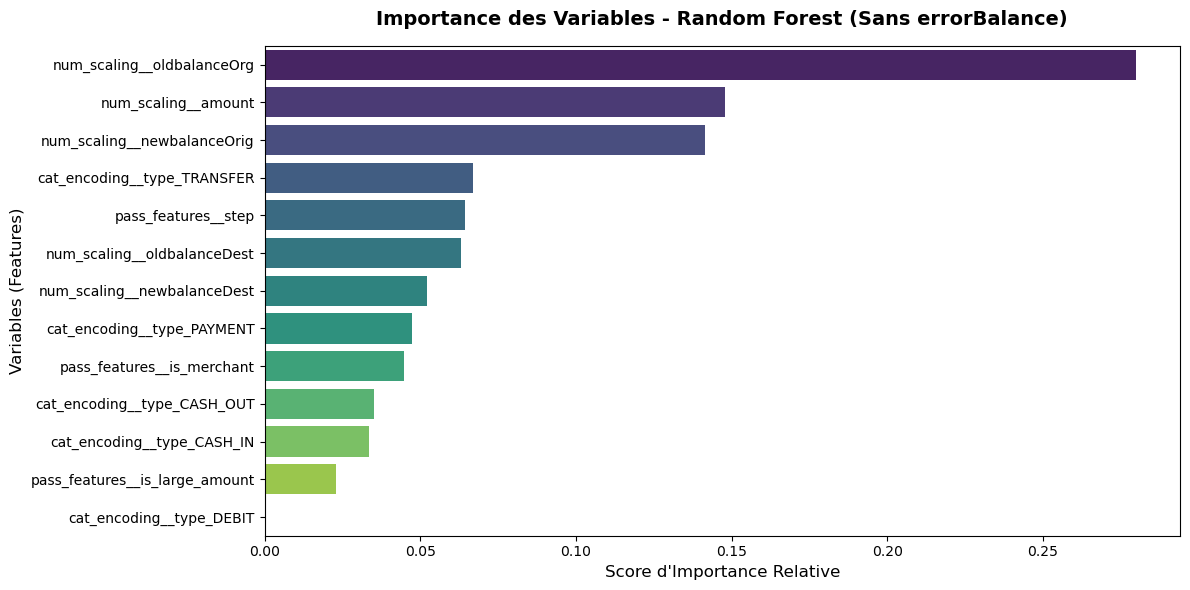

--- Top 5 des variables les plus discriminantes ---
                    Feature  Importance
 num_scaling__oldbalanceOrg    0.280020
        num_scaling__amount    0.147787
num_scaling__newbalanceOrig    0.141388
cat_encoding__type_TRANSFER    0.066984
        pass_features__step    0.064422


In [9]:
# ==============================================================================
# VISUALIZING FEATURE IMPORTANCE FOR THE RANDOM FOREST (NOTEBOOK 2)
# ==============================================================================

# 1. Extraction de l'importance des variables calcules par le Random Forest
importances = rf_model.feature_importances_
feature_names = X_train_final.columns

# Creation d'un DataFrame pour organiser les donnees par ordre decroissant
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 2. Creation du graphique avec Seaborn et Matplotlib
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance,
    palette='viridis'
)

# Ajout des titres et labels avec un style epure
plt.title("Importance des Variables - Random Forest (Sans errorBalance)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Score d'Importance Relative", fontsize=12)
plt.ylabel("Variables (Features)", fontsize=12)
plt.tight_layout()

# Affichage du graphique dans le notebook
plt.show()

# 3. Affichage textuel du Top 5 pour le rapport ecrit
print("--- Top 5 des variables les plus discriminantes ---")
print(df_importance.head(5).to_string(index=False))